# Analyse univariée et bivariée des données
## TP fil rouge : Parcoursup 2025

**Données** : formations proposées sur Parcoursup en 2025 (ministère de l'Enseignement supérieur, data.enseignementsup-recherche.gouv.fr).

**Organisation** : en binôme, un dépôt GitHub par binôme. Un commit à la fin de chaque partie.

Pour chaque question : du code, **et** une interprétation rédigée. Un chiffre sans phrase ne vaut rien.

---

### 🎯 La question de l'enquête

> **Qu'est-ce qui rend une formation sélective sur Parcoursup ?**

La sélectivité se mesure avec `taux_acces_ens` : la part des candidats qui ont reçu une proposition d'admission. Plus il est **bas**, plus la formation est **sélective**.

Chaque partie du TP fait avancer l'enquête. À la fin de chaque jour, vous rédigez une synthèse : *ce qu'on sait à ce stade sur la sélectivité*. La conclusion finale fait partie du TP noté.

# J1 matin — Comprendre les fondements de l'univarié

## Mise en place

Créez votre dépôt GitHub, clonez-le, placez `parcoursup.csv` dans un dossier `data/`.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Chargez le fichier (séparateur : `;`). Combien de lignes et de colonnes ?

In [8]:
df = pd.read_csv('data\parcoursup.csv', sep=';', index_col=0)
df 

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\User\AppData\Local\Temp\ipykernel_8404\3549075661.py:1: SyntaxWarning: invalid escape sequence '\p'
  df = pd.read_csv('data\parcoursup.csv', sep=';', index_col=0)


C:\Users\User\AppData\Local\Temp\ipykernel_8404\3549075661.py:1: DtypeWarning: Columns (110: detail_forma2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data\parcoursup.csv', sep=';', index_col=0)


,contrat_etab,cod_uai,g_ea_lib_vx,dep,dep_lib,region_etab_aff,acad_mies,ville_etab,lib_for_voe_ins,select_form,...,tri,cod_aff_form,detail_forma2,lien_form_psup,taux_acces_ens,part_acces_gen,part_acces_tec,part_acces_pro,etablissement_id_paysage,composante_id_paysage
session,,,,,,,,,,,,,,,,,,,,,
2025,Public,0121471J,Institut national universitaire Champollion - ...,12,Aveyron,Occitanie,Toulouse,Rodez,Licence - Sciences et Techniques des Activités...,formation non sélective,...,1_universités,2519,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,7.0,93,5,2,NaN,NaN
2025,Privé enseignement supérieur,0753605L,FAC LIBRE THEOLOGIE PROTESTANT,75,Paris,Ile-de-France,Paris,Paris 14e Arrondissement,Licence - Théologie - Parcours Théologie prote...,formation non sélective,...,1_universités,25320,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,100.0,90,5,5,NaN,NaN
2025,Privé enseignement supérieur,0951809A,CY ILEPS,95,Val-d'oise,Ile-de-France,Versailles,Cergy,Licence - Sciences de l'éducation et de la for...,formation sélective,...,1_universités,25370,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,77.0,80,16,5,NaN,NaN
2025,Public,0922671D,I.U.T de Ville d'Avray - Antenne de Nanterre,92,Hauts-de-Seine,Ile-de-France,Versailles,Nanterre,BUT - Techniques de commercialisation,formation sélective,...,1_universités,25438,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,12.0,48,52,0,NaN,NaN
2025,Privé enseignement supérieur,0690195M,Institut Catholique de Lyon,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Lyon 2e Arrondissement,Licence - Double diplôme - Licence Droit - Dou...,formation sélective,...,1_universités,25443,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,60.0,100,0,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025,Privé sous contrat d'association,0754030Y,Lycée Albert de Mun,75,Paris,Ile-de-France,Paris,Paris 7e Arrondissement,Mise à niveau - Hôtellerie restauration,formation sélective,...,3_Autres formations,9500,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,69.0,61,26,14,NaN,NaN
2025,Privé sous contrat d'association,0754030Y,Lycée Albert de Mun,75,Paris,Ile-de-France,Paris,Paris 7e Arrondissement,Diplôme de Comptabilité et de Gestion,formation sélective,...,3_Autres formations,9501,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,53.0,73,27,0,NaN,NaN
2025,Public,0754476H,Lycée des Métiers de l'Hôtellerie Guillaume TIREL,75,Paris,Ile-de-France,Paris,Paris 14e Arrondissement,Mise à niveau - Hôtellerie restauration,formation sélective,...,3_Autres formations,9541,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,16.0,72,19,9,NaN,NaN


## 1. Typologie des variables

🎯 *Enquête* : avant de chercher ce qui explique la sélectivité, il faut savoir quelles variables on a et comment les traiter.

Classez au moins ces colonnes : `fili`, `contrat_etab`, `select_form`, `cod_uai`, `capa_fin`, `voe_tot`, `taux_acces_ens`, `pct_bours`. Pour chacune : codage (ce que voit pandas), nature statistique, traitement retenu et justification.

| Variable       | Codage | Nature statistique    | Traitement retenu    | Justification                                                                                            |
| -------------- | ------ | --------------------- | -------------------- | -------------------------------------------------------------------------------------------------------- |
| fili           | string | nominale              | discrétiser | Les filières sont des catégories de fotmation et sans ordre.  |
| contrat_etab   | string | nominale              | fréquence / comptage | Les catégories représentent différents types d’établissement, sans ordre naturel.                        |
| select_form    | string | nominale              | fréquence / comptage | Il y a 2 catégories sans ordre naturel. On peut compter les occurrences de chacune.                      |
| cod_uai        | string | nominale              | aucun                | Il s’agit d’un identifiant d’établissement. Les codes ne représentent pas une quantité ni un ordre.      |
| capa_fin       | entier | quantitative discrète | aucun                | C’est un nombre de places. Les valeurs sont entières et peuvent être conservées telles quelles.          |
| voe_tot        | entier | quantitative discrète | aucun                | C’est un nombre de vœux. Il s’agit d’un comptage avec des valeurs entières.                              |
| taux_acces_ens | réel   | quantitative continue | aucun                | C’est un taux exprimé en pourcentage. Il peut être conservé comme valeur numérique.                      |
| pct_bours      | réel   | quantitative continue | aucun                | C’est un pourcentage qui peut être conservé comme valeur numérique.                                      |


> 💾 **Commit** : « Typologie des variables »

## 2. Tendance centrale

🎯 *Enquête* : à quoi ressemble une formation « typique » ? Est-elle sélective ? On regarde d'abord la sélectivité, puis deux causes possibles : la demande (`voe_tot`) et la taille (`capa_fin`).

**2.1** Moyenne et médiane de `taux_acces_ens`. Que remarquez-vous ?

In [9]:
moyenne_ta = df['taux_acces_ens'].mean()
mediane_ta = df['taux_acces_ens'].median()
print ("Moyenne_ta :", moyenne_ta)
print ("Médiane_ta :", mediane_ta)

Moyenne_ta : 56.14736250614596
Médiane_ta : 54.0


**Interprétation** : on constate que la moyenne est proche de la médiane, alors les données sont assez symetrique. alors les formations sont pas assez sélectives et plus d'1 personne reçoit une acceptaion.

**2.2** Moyenne et médiane de `voe_tot`. Une formation très demandée sera-t-elle forcément sélective ? Gardez la question en tête.

In [10]:
moyenne = df['voe_tot'].mean()
mediane = df['voe_tot'].median()
print("Moyenne voeux totaux :", moyenne)
print("Médiane :", mediane)

Moyenne voeux totaux : 947.4028206567499
Médiane : 385.0


**Interprétation** :la moyenne est largement surperieur à médiane. Alors une formation reçoit en médiane 385 voeux, la moyenne de voeux est élévée parce qu'il y a des formations qui reçoivent plus de voeux. Mais cela ne veut pas dire que plus une formation est demandé plus elle est sélective


**2.3** Quelle formation a la plus grande capacité (`capa_fin`) ? Que deviennent la moyenne et la médiane sans elle ?

In [11]:
# Formation avec la plus grande capacité
max_cap = df['capa_fin'].max()
formation_max = df.loc[df['capa_fin'].idxmax(), 'lib_for_voe_ins']

print("Capacité maximale :", max_cap)
print("Formation concernée :", formation_max)

Capacité maximale : 3400
Formation concernée : session
2025    Licence - Sciences et Techniques des Activités...
2025    Licence - Théologie - Parcours Théologie prote...
2025    Licence - Sciences de l'éducation et de la for...
2025                BUT - Techniques de commercialisation
2025    Licence - Double diplôme - Licence Droit - Dou...
                              ...                        
2025              Mise à niveau - Hôtellerie restauration
2025                Diplôme de Comptabilité et de Gestion
2025              Mise à niveau - Hôtellerie restauration
2025    Classe préparatoire aux études supérieures - S...
2025                                         Architecture
Name: lib_for_voe_ins, Length: 14252, dtype: str


In [12]:
df_sans_max = df[df['capa_fin'] != max_cap]
print("Moyenne de capa_fin :", df['capa_fin'].mean())
print("Médiane de capa_fin :", df['capa_fin'].median())
print("Moyenne sans la plus grande capacité :", df_sans_max['capa_fin'].mean())
print("Médiane sans la plus grande capacité :", df_sans_max['capa_fin'].median())

Moyenne de capa_fin : 53.98196744316587
Médiane de capa_fin : 30.0
Moyenne sans la plus grande capacité : 53.747175636797415
Médiane sans la plus grande capacité : 30.0


**Interprétation** : On constate que la médiane avec ou sans la cap max reste la même, maisla moyenne diminue légérèment.ça veut dire Cela indique que la capacité typique des formations est d’environ 30 places, et que quelques formations très grandes tirent légèrement la moyenne vers le haut

**2.4** Mode de `fili` et de `contrat_etab`.

In [13]:
mode_fili = df['fili'].mode()
print ("Mode :", mode_fili)
mode_contrat_etab = df['contrat_etab'].mode()
print ("Mode :", mode_contrat_etab)


Mode : 0    BTS
Name: fili, dtype: str
Mode : 0    Public
Name: contrat_etab, dtype: str


**Interprétation** : on constate que la formation qui apparait le plus c'est le bts et plus dans des établissements publics.

> 💾 **Commit** : « Tendance centrale »

## 3. Dispersion

🎯 *Enquête* : les formations sont-elles toutes à peu près aussi sélectives, ou y a-t-il de grands écarts à expliquer ?

On étudie la dispersion de `voe_tot` de bout en bout, puis on la compare à `taux_acces_ens`.

**3.1** Étendue de `voe_tot` (minimum, maximum, étendue).

In [14]:
max_voe_tot = df['voe_tot'].max()
min_voe_tot = df['voe_tot'].min()
etendue = max_voe_tot - min_voe_tot
print("Valeur maximale de voe_tot :", max_voe_tot)
print("Valeur minimale de voe_tot :", min_voe_tot)
print("Étendue de voe_tot :", etendue)

Valeur maximale de voe_tot : 19404
Valeur minimale de voe_tot : 1
Étendue de voe_tot : 19403


**Interprétation** : l'étendue montre qu'il y a véritablement une asymétrie car la médiane est de 385 et la moyenne 947. On constate qu'il y a des formations plus demandées que d'autres. Cela indique une forte dispersion des niveaux de demande, ce qui peut expliquer une sélectivité très différente selon les formations.

**3.2** Variance pas à pas sur les **10 premières formations** : écarts à la moyenne, écarts au carré, somme des écarts. Calculez la variance en divisant par n, puis par n − 1. Vérifiez avec numpy et pandas.

In [15]:
df_10_formations = df.sample(n=10, random_state=35)

x = df_10_formations['voe_tot']

moyenne = x.mean()
    
ecarts = x - moyenne
ecarts_carres = ecarts**2

somme_carres = ecarts_carres.sum()

variance_population = somme_carres / len(x)

variance_echantillon = somme_carres / (len(x) - 1)

print("10 formations choisies :")
print(x)
print("\nMoyenne :", moyenne)
print("Écarts à la moyenne :", ecarts.to_list())
print("Écarts au carré :", ecarts_carres.to_list())
print("Somme des écarts au carré :", somme_carres)
print("Variance population (÷ n) :", variance_population)
print("Variance échantillon (÷ n-1) :", variance_echantillon)


print("\nVérification NumPy :")
print("var n =", np.var(x))
print("var n-1 =", np.var(x, ddof=1))

print("\nVérification pandas :")
print("var_n :", x.var(ddof=0))
print("var_n-1 :", x.var())

10 formations choisies :
session
2025    1263
2025    1799
2025    1322
2025    1355
2025     100
2025     131
2025     182
2025    1094
2025      27
2025     851
Name: voe_tot, dtype: int64

Moyenne : 812.4
Écarts à la moyenne : [450.6, 986.6, 509.6, 542.6, -712.4, -681.4, -630.4, 281.6, -785.4, 38.60000000000002]
Écarts au carré : [203040.36000000002, 973379.56, 259692.16000000003, 294414.76, 507513.75999999995, 464305.95999999996, 397404.16, 79298.56000000001, 616853.1599999999, 1489.9600000000019]
Somme des écarts au carré : 3797392.4000000004
Variance population (÷ n) : 379739.24000000005
Variance échantillon (÷ n-1) : 421932.4888888889

Vérification NumPy :
var n = 379739.24000000005
var n-1 = 421932.4888888889

Vérification pandas :
var_n : 379739.24000000005
var_n-1 : 421932.4888888889


**Interprétation** : le degré de liberté à un impact, aussi les valeur sont ecartées vu qu'il ya une forte dispersion. Certaines formations sont beaucoup plus demandées que d’autres, et cet écart est visible dans les valeurs élevées de variance.

**3.3** Calculez tous les indicateurs de dispersion de `voe_tot` : variance, écart-type, écart absolu moyen, Q1, Q3, IQR, coefficient de variation. Comparez l'écart-type, l'écart absolu moyen et l'IQR.

In [16]:
variance_voe_tot = df['voe_tot'].var()
ecart_type_voe_tot = df['voe_tot'].std()
mae_voe_tot = (df['voe_tot'] - moyenne).abs().mean()
coefficient_variation = ecart_type_voe_tot / moyenne
Q1 = df['voe_tot'].quantile(0.25)
Q3 = df['voe_tot'].quantile(0.75)
IQR = Q3 - Q1
print ("Variance de voe_tot :", variance_voe_tot)
print ("Écart type de voe_tot :", ecart_type_voe_tot)
print ("Ecart absolu moyen :", mae_voe_tot)
print ("Coefficient de variation de voe_tot :", coefficient_variation)
print ("Premier quartile de voe_tot :", Q1)
print ("Troisième quartile de voe_tot :", Q3)
print ("Étendue interquartile de voe_tot :", IQR)

Variance de voe_tot : 2509634.0870399703
Écart type de voe_tot : 1584.182466460215
Ecart absolu moyen : 871.7116895874263
Coefficient de variation de voe_tot : 1.9500030360170053
Premier quartile de voe_tot : 160.0
Troisième quartile de voe_tot : 1016.0
Étendue interquartile de voe_tot : 856.0


**Interprétation** : IQR est proche du mae et l’écart-type de 1584,18 est sensiblement plus élevé que l’écart absolu moyen de 871,71 et que l’IQR de 856,0, ce qui indique une forte dispersion asmétrique. Cela indique que la demande en vœux est très dispersée et qu’elle est notamment tirée vers le haut par quelques formations très demandées. La moitié centrale des formations se situe entre 160 et 1016 vœux, mais la dispersion globale reste forte.

**3.4** Comparez la dispersion de `voe_tot` et de `taux_acces_ens` (écart-type, IQR, coefficient de variation). Laquelle est la plus dispersée ? Qu'est-ce que ça dit des écarts de sélectivité entre formations ?

In [17]:
variance_ta = df['taux_acces_ens'].var()
ecart_type_ta = df['taux_acces_ens'].std()
mae = (df['taux_acces_ens'] - moyenne_ta).abs().mean()
coefficient_variation_ta = ecart_type_ta / moyenne_ta
Q1_ta = df['taux_acces_ens'].quantile(0.25)
Q3_ta = df['taux_acces_ens'].quantile(0.75)
IQR_ta = Q3_ta - Q1_ta
print ("Variance de taux_acces_ens :", variance_ta)
print ("Écart-type de taux_acces_ens :", ecart_type_ta)
print ("MAE de taux_acces_ens :", mae)
print ("Coefficient de variation de taux_acces_ens :", coefficient_variation_ta)
print ("Q1 de taux_acces_ens :", Q1_ta)
print ("Q3 de taux_acces_ens :", Q3_ta)
print ("IQR de taux_acces_ens :", IQR_ta)

Variance de taux_acces_ens : 817.4264423617664
Écart-type de taux_acces_ens : 28.590670547606372
MAE de taux_acces_ens : 24.519874203921514
Coefficient de variation de taux_acces_ens : 0.5092077218137682
Q1 de taux_acces_ens : 33.0
Q3 de taux_acces_ens : 81.0
IQR de taux_acces_ens : 48.0


**Interprétation** : On remarque que par rapport aux voeux, la dispersion est plus centrée et assez symétrique et que l'écart-type est superieur à l'écart absolu moyen (MAE) et inferieur à l'écart inter-quartile (IQR). Ce qui indique la demande est présente, que les niveaux de demande varient beaucoup plus fortement d’une formation à l’autre que les taux d’accès. Les écarts de sélectivité existent, mais ils sont moins importants que les écarts de volume de demandes entre formations.

> 💾 **Commit** : « Dispersion »

## 4. Graphiques

🎯 *Enquête* : voir la sélectivité, et trouver un premier indice de ce qui la fait varier.

**4.1** Histogramme de `taux_acces_ens`. À quelle forme vous attendiez-vous ? Qu'obtenez-vous ?

Text(0.5, 1.0, 'Histogramme de taux_acces_ens')

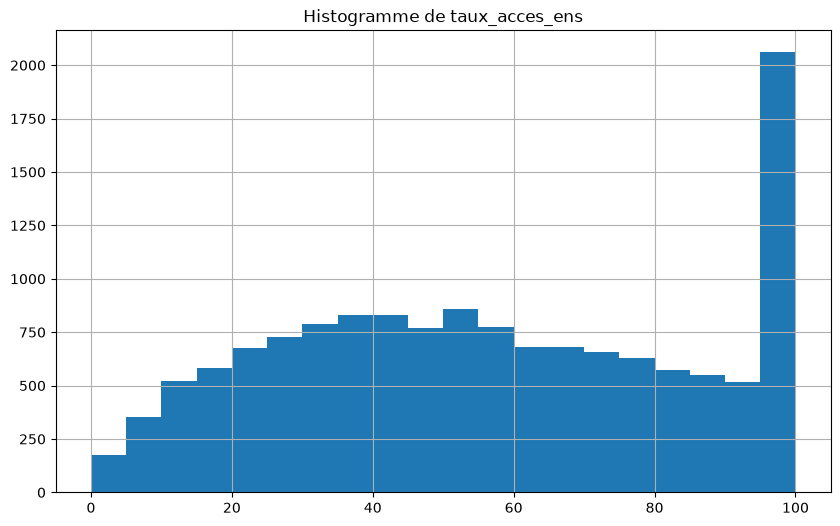

In [21]:
plt.figure(figsize=(10, 6))
hist_taux_acces_ens = df['taux_acces_ens'].hist(bins=20)
plt.title("Histogramme de taux_acces_ens")

**Interprétation** : Nous pouvons dire que l'histogramme du taux d'accès aux formations est plus tirée vers la gauche. Donc, il y a un très grand nombre de formations sélectives, beaucoup plus que les formations non sélectives. Sachant comment se calcule le taux d'accès, le nombre de demandes ou de personnes en attente est assez bas. D'où le fait que les formations peuvent être vraiment qualifiées de très sélectives et qui ne poussent pas les demander à cause de l'intertitude d'accès à ces formations.

**4.2** Diagramme en barres de `fili`, trié par effectif.

Text(0.5, 1.0, 'Histogramme de voe_tot')

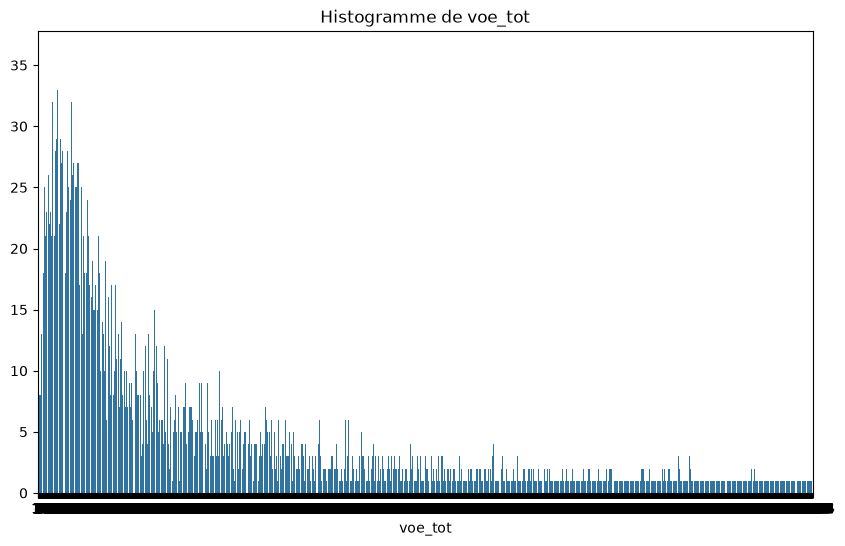

In [ ]:
#diagramme en barre
import seaborn as sns
plt.figure(figsize=(10, 6))
hist_voe_tot = sns.barplot(x=df['voe_tot'].value_counts().index, y=df['voe_tot'].value_counts().values, bin =)
plt.title("Histogramme de voe_tot")

**4.2 bis** Camembert de `contrat_etab`, puis camembert de `fili`. Lequel est lisible ? Pourquoi ?

Text(0.5, 1.0, 'Répartition des filières')

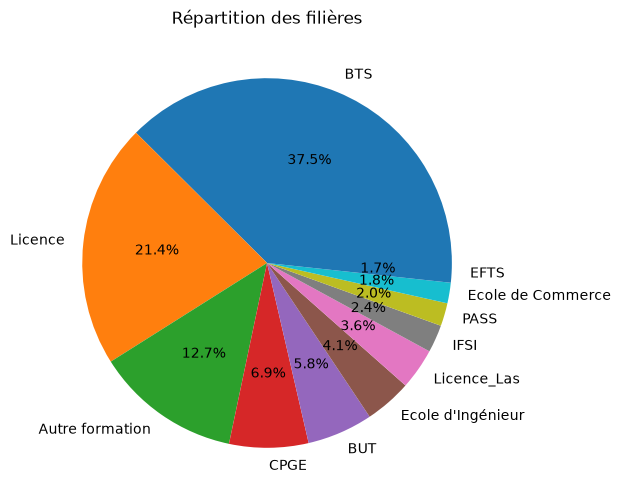

In [22]:
plt.figure(figsize=(10, 6))
plt.pie(df['fili'].value_counts(), labels=df['fili'].value_counts().index, autopct='%1.1f%%')
plt.title("Répartition des filières")

**Interprétation** : _à rédiger_

**4.3** Boxplot de `voe_tot`. Est-il lisible ? Que faudrait-il faire ?

<Axes: xlabel='voe_tot'>

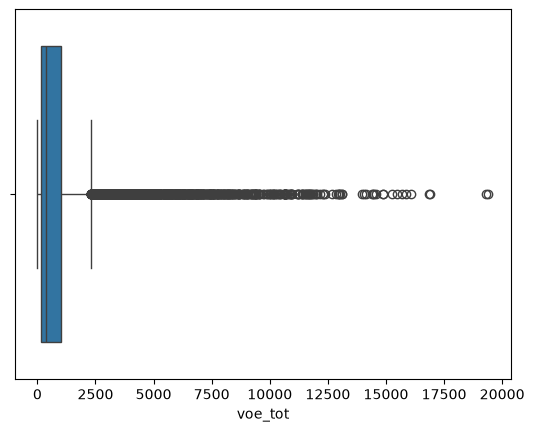

In [23]:
sns.boxplot(x='voe_tot', data=df)

**Interprétation** : _à rédiger_

**4.4** Boxplots de `taux_acces_ens` selon `select_form`. Premier indice : le label « sélective » correspond-il vraiment à un taux d'accès plus faible ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Graphiques », puis **push**.

# J1 après-midi — Approfondir les distributions

In [ ]:
from scipy import stats

## 5. Asymétrie et aplatissement

🎯 *Enquête* : la forme des variables décidera des outils à utiliser au J2 pour les relier à la sélectivité.

**5.1** Calculez la skewness et la kurtosis de `voe_tot`, `taux_acces_ens`, `capa_fin` et `pct_bours`. Classez-les de la plus symétrique à la plus asymétrique. Lesquelles faudra-t-il transformer avant de les relier à la sélectivité ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Asymétrie »

## 6. La loi normale

🎯 *Enquête* : peut-on utiliser sur la sélectivité les outils qui supposent une loi normale ?

**6.1** Vérifiez la règle 68-95-99,7 sur `taux_acces_ens`. La variable suit-elle une loi normale ? Quelle conséquence pour la suite de l'enquête ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Loi normale »

## 7. Les distributions réelles

🎯 *Enquête* : la demande (`voe_tot`) est une cause possible de sélectivité. Quelle échelle faudra-t-il utiliser pour la comparer au taux d'accès ?

**7.1** Tracez l'histogramme de `voe_tot`, puis celui de `log(voe_tot)`. Quelle loi reconnaissez-vous ? Quelle échelle utiliserez-vous au J2 pour relier la demande à la sélectivité ?

**Interprétation** : _à rédiger_

**7.2** Quelle part des vœux concentrent les 10 % et les 20 % de formations les plus demandées ? Est-ce une distribution de type Pareto ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Distributions »

## 8. Outliers

🎯 *Enquête* : les formations hors norme risquent de fausser les liens avec la sélectivité. Faut-il les garder ?

**8.1** Détectez les outliers de `capa_fin` avec la méthode IQR, puis avec le Z-score (|z| > 3). Comparez les nombres obtenus et expliquez l'écart.

**Interprétation** : _à rédiger_

**8.2** Affichez les 10 plus grandes capacités. S'agit-il d'erreurs ou de valeurs réelles ? Que faites-vous ? Les garderez-vous pour étudier la sélectivité ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Outliers », puis **push**.

## 9. Analyse univariée en autonomie

🎯 *Enquête* : deux nouveaux suspects. Le profil social des admis et la région peuvent-ils jouer sur la sélectivité ?

Vous disposez maintenant de toute la méthode. Analysez **seuls** les deux variables suivantes, en suivant les étapes ci-dessous :
- une variable **quantitative** : `pct_bours` (part de boursiers parmi les admis, en %) ;
- une variable **qualitative** : `region_etab_aff` (région de l'établissement).

| Étape | Variable quantitative | Variable qualitative |
|---|---|---|
| 1. Comprendre | Ce qu'elle mesure, son unité, discrète ou continue | Nominale ou ordinale, liste des modalités |
| 2. Qualité | Valeurs manquantes, 0 suspects, bornes | Valeurs manquantes, modalités mal orthographiées |
| 3. Centre | Moyenne et médiane, comparées | Mode (et médiane si ordinale) |
| 4. Dispersion | σ, IQR, CV | Nombre de modalités, part de la modalité dominante |
| 5. Visualiser | Histogramme, boxplot | Diagramme en barres |
| 6. Forme | Skewness, kurtosis, QQ-plot : quelle loi ? | Répartition équilibrée ou concentrée, modalités rares |
| 7. Extrêmes | IQR ou Z-score selon la forme, puis inspection | — |
| 8. Conclure | Quel résumé, quels outils pour la suite ? | Quel regroupement, quel encodage pour la suite ? |

> Chaque chiffre s'interprète en une phrase.

### Variable quantitative : `pct_bours`

**Analyse** : _à rédiger_

### Variable qualitative : `region_etab_aff`

**Analyse** : _à rédiger_

> 💾 **Commit** : « Analyse univariée », puis **push**.

## 📝 Synthèse J1 — Ce qu'on sait sur la sélectivité

- À quoi ressemble la sélectivité d'une formation typique ? Les formations sont-elles proches ou très différentes ?
- Quels premiers indices avez-vous trouvés sur ce qui la fait varier ?
- Quelles variables faudra-t-il transformer pour la suite, et pourquoi ?

4 à 6 lignes.

**Synthèse** : _à rédiger_

> 💾 **Commit** : « Synthèse J1 », puis **push**.

# J2 matin — Mettre en pratique les fondements mathématiques de la corrélation

## 10. Covariance

🎯 *Enquête* : on passe au bivarié. On apprend d'abord à mesurer un lien sur un couple simple (capacité × vœux), avant de l'appliquer à la sélectivité.

**10.1** Tracez le nuage de points de `voe_tot` en fonction de `capa_fin`. Calculez leur covariance à la main (produits des écarts), puis avec pandas.

**Interprétation** : _à rédiger_

**10.2** Recalculez la covariance avec la capacité exprimée en centaines de places. Que constatez-vous ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Covariance »

## 11. Corrélation de Pearson

🎯 *Enquête* : première mesure chiffrée du lien entre la demande et la sélectivité.

**11.1** Calculez r entre `capa_fin` et `voe_tot` à la main (covariance / produit des écarts-types), puis avec pandas. Faites de même pour `voe_tot` et `taux_acces_ens`. Que dit ce second coefficient sur la sélectivité ?

**Interprétation** : _à rédiger_

**11.2** Les conditions de Pearson sont-elles respectées ? Recalculez r entre `log(capa_fin)` et `log(voe_tot)` (en excluant les valeurs nulles).

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Pearson »

## 12. Corrélation de Spearman

🎯 *Enquête* : le lien demande × sélectivité est-il sous-estimé par Pearson ?

**12.1** Calculez Spearman pour les deux couples de la question 11.1. Comparez avec Pearson et expliquez les écarts.

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Spearman »

## 13. Tests d'hypothèse

🎯 *Enquête* : le lien entre demande et sélectivité est-il réel, ou dû au hasard ? Et quel coefficient retenir pour la suite ?

**13.1** Testez la normalité de `taux_acces_ens` avec Shapiro-Wilk et Anderson-Darling, sur un échantillon de 50 formations puis sur toutes. Formulez H0 et concluez. Quel coefficient de corrélation retiendrez-vous pour la suite de l'enquête ?

**Interprétation** : _à rédiger_

**13.2** Testez la corrélation entre `voe_tot` et `taux_acces_ens` (Spearman). Formulez H0, donnez la p-value et concluez. Le lien est-il fort pour autant ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Tests », puis **push**.

# J2 après-midi — Approfondir les relations quantitatives

## 14. Corrélation partielle

🎯 *Enquête* : le lien entre demande et sélectivité tient-il à capacité égale ?

**14.1** Calculez la corrélation entre `log(voe_tot)` et `taux_acces_ens`, puis la corrélation partielle en contrôlant `log(capa_fin)`. Que concluez-vous ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Corrélation partielle »

## 15. A/B testing

🎯 *Enquête* : un lien observé suffit-il à affirmer qu'un facteur *cause* la sélectivité ?

**15.1** Au J3, vous verrez que les formations privées ont un taux d'accès plus élevé que les publiques. Peut-on en conclure que le statut privé *rend* une formation moins sélective ? Quelle expérience faudrait-il pour le prouver, et est-elle possible ici ?

**Interprétation** : _à rédiger_

**15.2** Reprenez la simulation de la démo avec 500 visiteurs, puis 20 000. Une version B qui fait passer le taux d'achat de 20 % à 22 %. L'effet est-il détecté dans les deux cas ? Pourquoi ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « A/B testing »

## 16. Matrice de corrélation

🎯 *Enquête* : vue d'ensemble. Quelles variables quantitatives sont liées à la sélectivité, et lesquelles disent la même chose ?

**16.1** Tracez la heatmap des corrélations de Spearman entre `capa_fin`, `voe_tot`, `acc_tot`, `taux_acces_ens`, `pct_bours`, `pct_f`, `pct_tb`. Quelles variables sont redondantes ? Quelles variables sont les meilleures candidates pour expliquer la sélectivité ?

**Interprétation** : _à rédiger_

## 17. Régression simple

🎯 *Enquête* : le niveau scolaire des admis explique-t-il la sélectivité, et dans quelle mesure ?

**17.1** Régressez `taux_acces_ens` sur `pct_tb` (part de mentions très bien parmi les admis). Donnez la pente, le R², et tracez les résidus. Les mentions TB expliquent-elles la sélectivité ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Régression », puis **push**.

## 📝 Synthèse J2 — Ce qu'on sait sur la sélectivité

- Quelles variables quantitatives sont liées à la sélectivité, avec quelle force ?
- Le lien avec la demande tient-il quand on contrôle la taille ?
- Peut-on parler de causes ? Pourquoi ?

4 à 6 lignes.

**Synthèse** : _à rédiger_

> 💾 **Commit** : « Synthèse J2 », puis **push**.

# J3 matin — Comprendre les fondements du bivarié qualitatif

## 18. Table de contingence et Chi²

🎯 *Enquête* : le label « formation sélective » dépend-il du statut de l'établissement ?

**18.1** Croisez `select_form` et `contrat_etab` : table des effectifs, puis fréquences conditionnelles par statut.

**Interprétation** : _à rédiger_

**18.2** Faites le test du Chi² d'indépendance (H0, effectifs théoriques, p-value), puis calculez le V de Cramér et les résidus standardisés.

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Chi² »

## 19. Quantitatif × qualitatif

🎯 *Enquête* : la sélectivité varie-t-elle selon le statut (public / privé) et selon la filière ?

**19.1** Le `taux_acces_ens` diffère-t-il entre formations publiques et privées ? Boxplot, Student (Welch) et Mann-Whitney.

**Interprétation** : _à rédiger_

**19.2** Le `taux_acces_ens` diffère-t-il selon la filière (`fili`) ? ANOVA et Kruskal-Wallis. Quelles filières sont les plus sélectives ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Quanti × quali », puis **push**.

# J3 après-midi — Introduire le multivarié

## 20. ACP

🎯 *Enquête* : on rassemble toutes les variables. Où se place la sélectivité parmi elles ?

**20.1** Faites une ACP sur `log(capa_fin)`, `log(voe_tot)`, `taux_acces_ens`, `pct_bours`, `pct_f`, `pct_tb` (centrées-réduites). Quelle part de variance portent les deux premiers axes ? Interprétez-les à partir des contributions. Où se place `taux_acces_ens` sur ces axes ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « ACP », puis **push**.

## 🏁 Conclusion de l'enquête

Répondez à la question : **qu'est-ce qui rend une formation sélective sur Parcoursup ?**

- Les facteurs retenus, classés par importance, chacun appuyé par un chiffre du TP.
- Les pistes écartées.
- Les limites : ce que vos analyses ne permettent pas d'affirmer.

10 à 15 lignes. Cette conclusion compte dans la note du TP.

**Synthèse** : _à rédiger_

> 💾 **Commit** : « Conclusion de l'enquête », puis **push**.